LAB 5

In [37]:
#pip install ucimlrepo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

1. Data loading

In [39]:
try:
    from ucimlrepo import fetch_ucirepo

    student_performance = fetch_ucirepo(id=320)
    X_raw = student_performance.data.features.copy()
    y_raw = student_performance.data.targets.copy()
    df = pd.concat([X_raw, y_raw], axis=1)
except Exception as error:
    local_path = Path('student') / 'student-por.csv'
    df = pd.read_csv(local_path, sep=';')


In [40]:
print('\nFirst 5 rows:')
df.head()



First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [41]:
print('\nDataset shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)

print('\nInference:')
print(f'The dataset contains {df.shape[0]} samples and {df.shape[1]} total columns.\nIt includes categorical and numerical variables, so preprocessing is required before model training.')


Dataset shape: (649, 33)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences 

2. Data Preprocessing

In [42]:
missing_before = df.isnull().sum()
print('Missing values before preprocessing:')
print(missing_before[missing_before > 0] if missing_before.sum() > 0 else 'No missing values found.')

processed_df = df.copy()

for column in processed_df.columns:
    if processed_df[column].isnull().sum() > 0:
        if processed_df[column].dtype == 'object':
            processed_df[column] = processed_df[column].fillna(processed_df[column].mode()[0])
        else:
            processed_df[column] = processed_df[column].fillna(processed_df[column].median())

categorical_columns = processed_df.select_dtypes(include='object').columns.tolist()
processed_df = pd.get_dummies(processed_df, columns=categorical_columns, drop_first=True)

target_column = 'G3'
feature_columns = [column for column in processed_df.columns if column != target_column]

scaler = StandardScaler()
processed_df[feature_columns] = scaler.fit_transform(processed_df[feature_columns])


Missing values before preprocessing:
No missing values found.


In [43]:
print('\nProcessed dataset shape:', processed_df.shape)
processed_df.head()


Processed dataset shape: (649, 42)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,1.031695,1.310216,1.540715,0.576718,0.083653,-0.374305,0.072606,-0.171647,0.693785,-0.543555,...,0.652973,-0.259681,2.923032,-1.259229,-0.252853,-0.971140,0.495663,0.344914,-1.816043,-0.763496
1,0.210137,-1.336039,-1.188832,-0.760032,0.083653,-0.374305,1.119748,-0.171647,-0.157380,-0.543555,...,-1.531457,-0.259681,-0.342110,0.794137,-0.252853,-0.971140,-2.017502,0.344914,0.550648,-0.763496
2,-1.432980,-1.336039,-1.188832,-0.760032,0.083653,-0.374305,0.072606,-0.171647,-1.008546,0.538553,...,0.652973,-0.259681,2.923032,-1.259229,-0.252853,-0.971140,0.495663,0.344914,0.550648,-0.763496
3,-1.432980,1.310216,-0.278983,-0.760032,1.290114,-0.374305,-0.974536,-1.123771,-1.008546,-0.543555,...,0.652973,-0.259681,-0.342110,0.794137,-0.252853,1.029717,0.495663,0.344914,0.550648,1.309764
4,-0.611422,0.428131,0.630866,-0.760032,0.083653,-0.374305,0.072606,-0.171647,-1.008546,-0.543555,...,-1.531457,-0.259681,-0.342110,0.794137,-0.252853,-0.971140,0.495663,0.344914,-1.816043,-0.763496


In [44]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

3. Feature Selection

In [45]:
target_column = 'G3'
X = processed_df.drop(columns=[target_column]).values
y = processed_df[target_column].values

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (649, 41)
y shape: (649,)


Inference:
The selected target variable is G3, the final student grade.
There are 41 input features after encoding and preprocessing.

4. Train-Test Split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (519, 41)
X_test shape: (130, 41)
y_train shape: (519,)
y_test shape: (130,)


The training set contains 519 samples.
The testing set contains 130 samples.

5. Implement Gradient Descent Linear Regression

In [47]:
class GradientDescentLinearRegression:
    def __init__(self, learning_rate=0.01, iterations=2000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = 0.0
        self.loss_history = []

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def compute_cost(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.iterations):
            y_pred = self.predict(X)
            loss = self.compute_cost(y, y_pred)
            self.loss_history.append(loss)

            dw = -(2 / n_samples) * np.dot(X.T, (y - y_pred))
            db = -(2 / n_samples) * np.sum(y - y_pred)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self


model = GradientDescentLinearRegression(learning_rate=0.01, iterations=2000)
model.fit(X_train, y_train)

print('Initial loss:', model.loss_history[0])
print('Final loss:', model.loss_history[-1])

Initial loss: 149.6204238921002
Final loss: 1.4911388484325405


The substantial decrease from initial to final loss indicates that Gradient Descent successfully optimized the Linear Regression parameters. The decreasing loss confirms that the model is converging toward a minimum.

In [48]:
reduction = ((model.loss_history[0] - model.loss_history[-1]) / model.loss_history[0]) * 100
print(f'Loss reduction: {reduction:.2f}%')

Loss reduction: 99.00%


6. Learning Rate Experiment

In [49]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
loss_histories = {}
models = {}

for lr in learning_rates:
    lr_model = GradientDescentLinearRegression(learning_rate=lr, iterations=2000)
    lr_model.fit(X_train, y_train)
    loss_histories[lr] = lr_model.loss_history
    models[lr] = lr_model
    print(f'Learning rate {lr}: Initial loss = {lr_model.loss_history[0]:.4f}, Final loss = {lr_model.loss_history[-1]:.4f}')

stable_rates = [lr for lr in learning_rates if np.isfinite(loss_histories[lr][-1])]
best_learning_rate = min(stable_rates, key=lambda lr: loss_histories[lr][-1])
slowest_learning_rate = max(stable_rates, key=lambda lr: loss_histories[lr][-1])

Learning rate 0.001: Initial loss = 149.6204, Final loss = 1.6731
Learning rate 0.01: Initial loss = 149.6204, Final loss = 1.4911
Learning rate 0.05: Initial loss = 149.6204, Final loss = 1.4911
Learning rate 0.1: Initial loss = 149.6204, Final loss = 1.4911


The learning rate 0.1 reached the lowest final loss and achieved the lowest final loss among the tested learning rates among the tested values.
The learning rate 0.001 was slower or less effective based on the final loss comparison.

7. Plot Loss Curve

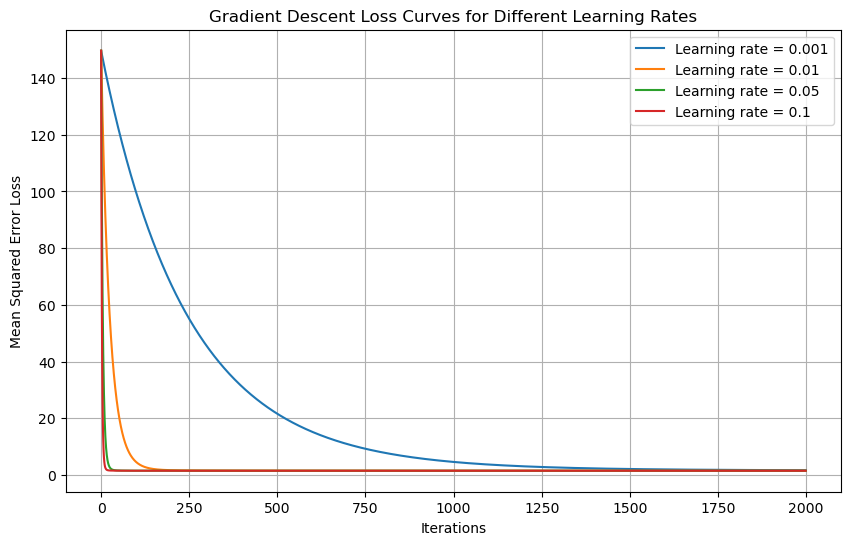

In [50]:
plt.figure(figsize=(10, 6))

for lr, losses in loss_histories.items():
    plt.plot(losses, label=f'Learning rate = {lr}')

plt.title('Gradient Descent Loss Curves for Different Learning Rates')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True)
plt.show()

The loss generally decreases over iterations as the model parameters are updated.
Convergence is achieved when the curve becomes nearly flat, indicating little further reduction in error.

8. Model Evaluation

In [51]:
final_model = models[best_learning_rate]
y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Final model learning rate:', best_learning_rate)
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')

Final model learning rate: 0.1
Mean Absolute Error (MAE): 0.7651
Mean Squared Error (MSE): 1.4759
Root Mean Squared Error (RMSE): 1.2149
R2 Score: 0.8487


Lower MAE, MSE, and RMSE values indicate better prediction accuracy on the grade scale.
A higher R2 score indicates that the model explains more variation in student performance.

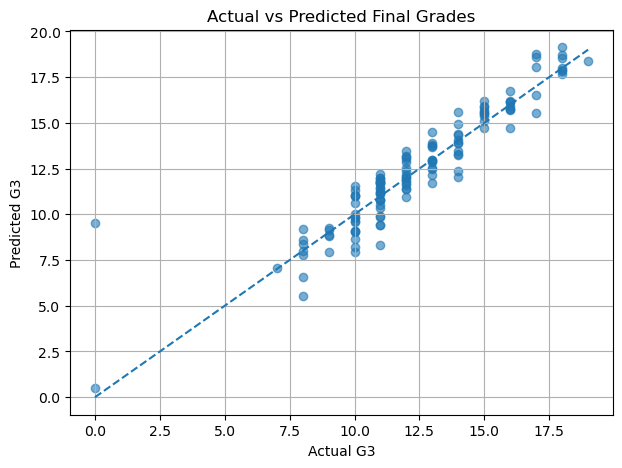

In [52]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs Predicted Final Grades')
plt.grid(True)
plt.show()

As we can see, predictions closer to the diagonal line indicate better model accuracy. The concentration of points around the line suggests that the model captures the relationship between the selected features and final grade reasonably well.

9. Final Interpretation

Final Interpretation:
The Student Performance dataset was loaded, checked for missing values, encoded, and scaled before model training.
The final grade G3 was selected as the target variable, while the remaining columns were used as input features.
Different learning rates affected how quickly Gradient Descent reduced the loss, with very small rates converging more slowly.
The loss curves show whether each learning rate reached stable convergence over the selected number of iterations.
The evaluation metrics measure how close the predicted grades are to the actual grades on the test set.
Overall, Gradient Descent successfully learned a linear relationship if the final loss decreased and the R2 score is reasonably high.